In [2]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv("../../data/height_weight.csv")

df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Weight')

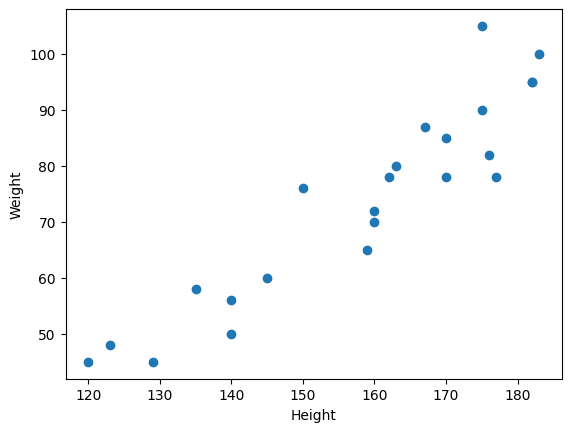

In [8]:
# scatter plot

plt.scatter(df["Height"], df["Weight"])

plt.xlabel("Height")
plt.ylabel("Weight")

In [10]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


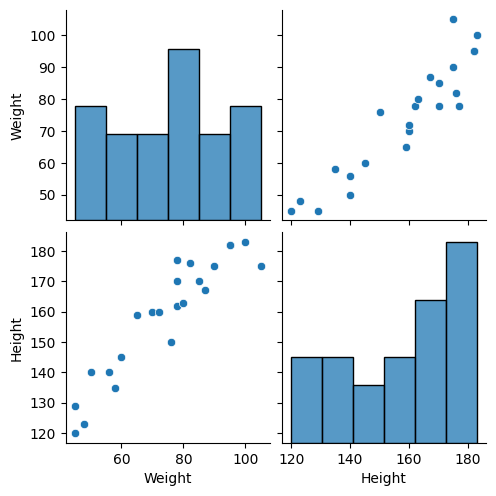

In [11]:
import seaborn as sns

sns.pairplot(df)

In [12]:
# defining independent and dependent features.

x = df[["Weight"]]          # independent variable should be stored in a dataframe or 2-dimensional array.

y = df["Height"]            # dependent variable can be in series or 1-dimensional array

In [13]:
x_series = df["Weight"]
np.array(x_series).shape

(23,)

In [14]:
np.array(y).shape

(23,)

In [ ]:
# train-test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

"""

For a given random state, the data is split into same exact way if we use that random state again.

For example,
    if the random_state is set 42, if someone or yourself if you run split the train & test data with random_state=42 again,
    we will get the same exact train, test split

    we force the split to be reproducible.

    that means:
        same rows go into training set
        same rows go into testing set
        every time you run the code

    So if someone else runs the same code with the same dataset and same random_state, they get the exact same split.

"""


In [19]:
# standardization of data

"""



"""

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

x_test

array([[ 0.2785895 ],
       [ 0.2785895 ],
       [-1.70918423],
       [ 1.30259415],
       [-0.50447288],
       [ 1.90494982],
       [-0.92612185]])

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(n_jobs=-1)

In [21]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
print("Coefficent or Slope (m): ", model.coef_)
print("Intercept (c): ", model.intercept_)

Coefficent or Slope (m):  [17.03207732]
Intercept (c):  157.8125


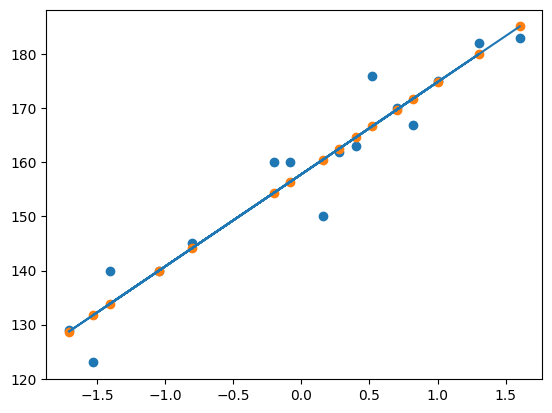

In [35]:
# plot training data and best fit line

plt.scatter(x_train, y_train)

plt.scatter(x_train, model.predict(x_train))
plt.plot(x_train, model.predict(x_train))

In [36]:
# prediction on test data

y_pred = model.predict(x_test)

In [ ]:
# performance metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mse)

print(mse)
print(rmse)

print(mae)

103.09818711844574
10.153727744944009
9.237776679921925


In [42]:
# r square

from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print(score)

0.7828485570493535


In [43]:
"""
Adjusted R^2

Adjusted R2 = 1 - [(1 - R2) * (n - 1) / (n - k - 1)]

where:

R2:     R2 score of the model
n:      the number of observations          (len of y_test)
k:      the number of predictor variables   (number of features used for prediction) 

"""

adjusted_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)
adjusted_r2

0.7394182684592242

In [45]:
# OLS Linear Regression

import statsmodels.api as sm

model = sm.OLS(x_train, y_train).fit()

In [46]:
y_pred = model.predict(x_test)

print(y_pred)

[ 0.00018815  0.00018815 -0.00115431  0.00087971 -0.0003407   0.00128652
 -0.00062546]


In [48]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.054
Method:                 Least Squares   F-statistic:                             0.1745
Date:                Wed, 13 May 2026   Prob (F-statistic):                       0.682
Time:                        12:23:54   Log-Likelihood:                         -22.610
No. Observations:                  16   AIC:                                      47.22
Df Residuals:                      15   BIC:                                      47.99
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:

"""

Linear Regression (To Do List):

    0) Handling Imbalanced Dataset [https://github.com/krishnaik06/Complete-Data-Science-With-Machine-Learning-And-NLP-2024/blob/main/3-Complete%20Linear%20Regression/Practicals/2.0-Handling%20Imbalance%20Dataset.ipynb]

    1) height_weight.csv (Completed) [https://github.com/krishnaik06/Complete-Data-Science-With-Machine-Learning-And-NLP-2024/blob/main/3-Complete%20Linear%20Regression/Practicals/simple%20linear%20regression.ipynb]
    2) california housing dataset (Completed) - [https://github.com/krishnaik06/Complete-Data-Science-With-Machine-Learning-And-NLP-2024/blob/main/3-Complete%20Linear%20Regression/Practicals/Linear%20Regression%20ML%20Implementation.ipynb]
    3) multiple linear regression - economics data, index price prediction [https://github.com/krishnaik06/Complete-Data-Science-With-Machine-Learning-And-NLP-2024/blob/main/3-Complete%20Linear%20Regression/Practicals/Multiple%20Linear%20Regression-%20Economics%20Dataset.ipynb]
    4) polynomial regression - dataset is produced/generated using a quadratic prediction [https://github.com/krishnaik06/Complete-Data-Science-With-Machine-Learning-And-NLP-2024/blob/main/3-Complete%20Linear%20Regression/Practicals/Polynomial%20Regression%20Implementation.ipynb]
    5) algerain forest fires dataset (Completed) [https://github.com/krishnaik06/Complete-Data-Science-With-Machine-Learning-And-NLP-2024/blob/main/3-Complete%20Linear%20Regression/Practicals/Model%20Training.ipynb]

    6) Ridge, Lasso Regression - [https://github.com/krishnaik06/Complete-Data-Science-With-Machine-Learning-And-NLP-2024/blob/main/3-Complete%20Linear%20Regression/Practicals/Ridge%2C%20Lasso%20Regression.ipynb]

"""
